In [1]:
import pandas as pd

import protfasta
import numpy as np
import requests
import re
import warnings
warnings.filterwarnings("ignore")
import glob


from Bio import AlignIO
import matplotlib.pyplot as plt
from Bio.Align import AlignInfo

from Bio.Align import MultipleSeqAlignment
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq


import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import metapredict

In [2]:
import os
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import protfasta
import statsmodels.api as sm



In [3]:
base_url = "https://genome.senckenberg.de/download/TOGA/human_hg38_reference/MultipleCodonAlignments/"


In [4]:
df = protfasta.read_fasta("../data/ENST00000263253.EP300.fasta", invalid_sequence_action = 'convert') #Convert - to ""
df = pd.DataFrame({"id" : df.keys(), "nt_seq" : df.values()})
df

,id,nt_seq
0,REFERENCE,ATGGCCGAGAATGTGGTGGAACCGGGGCCGCCTTCAGCCAAGCGGC...
1,vs_HLaciJub2\tENST00000263253.EP300.44,ATGGCCGAGAATGTGGTGGAACCGGGGCCGCCTTCAGCCAAGCGGC...
2,vs_vicPac2\tENST00000263253.EP300.60,ATGGCCGAGAATGTCGTGGAACCGGGGCCGCCTTCAGCCAAGCGGC...
3,vs_ursMar1\tENST00000263253.EP300.113,ATGGCCGAGAATGTGGTGGAACCGGGGCCGCCTTCAGCCAAGCGGC...
4,vs_HLacoRus1\tENST00000263253.EP300.65,ATGGCCGAGAATGTGGTGGAACCGGGGCCGCCTTCAGCCAAGCGGC...
...,...,...
479,vs_HLeryPat1\tENST00000263253.EP300.128234,GATTACTTTGATATTGTGAAGAGCCCCATGGATCTTTCTACCATTA...
480,vs_HLtolMat1\tENST00000263253.EP300.13447,GACTACTTTGATATTGTCAAGAGCCCCATGGATCTGTCTACCATCA...
481,vs_dasNov3\tENST00000263253.EP300.5277,CTTTCTCAGCCAGCTGTAAGCATTGAAGGGCTGGTATCAAACCGTC...
482,vs_HLlasBor1\tENST00000263253.EP300.18083,GCCCACTGTGCGTCTTCTCGACAAATCATCTCCCACTGGAAGAACT...


In [5]:
# Translate sequences
df["prot_seq"] = [str(Seq(_).translate())[:-1] for _ in df["nt_seq"]]
df

,id,nt_seq,prot_seq
0,REFERENCE,ATGGCCGAGAATGTGGTGGAACCGGGGCCGCCTTCAGCCAAGCGGC...,MAENVVEPGPPSAKRPKLSSPALSASASDGTDFGSLFDLEHDLPDE...
1,vs_HLaciJub2\tENST00000263253.EP300.44,ATGGCCGAGAATGTGGTGGAACCGGGGCCGCCTTCAGCCAAGCGGC...,MAENVVEPGPPSAKRPKLSSPALSASASDGTDFGSLFDLEHDLPDE...
2,vs_vicPac2\tENST00000263253.EP300.60,ATGGCCGAGAATGTCGTGGAACCGGGGCCGCCTTCAGCCAAGCGGC...,MAENVVEPGPPSAKRPKLSSPALSASASDGTMGMMNNPNPYSSPYT...
3,vs_ursMar1\tENST00000263253.EP300.113,ATGGCCGAGAATGTGGTGGAACCGGGGCCGCCTTCAGCCAAGCGGC...,MAENVVEPGPPSAKRPKLSSPALSASASDGTDFGSLFDLEHDLPDE...
4,vs_HLacoRus1\tENST00000263253.EP300.65,ATGGCCGAGAATGTGGTGGAACCGGGGCCGCCTTCAGCCAAGCGGC...,MAENVVEPGPPSAKRPKLSSPALSASASDGTDFGSLFDLEHDLPDE...
...,...,...,...
479,vs_HLeryPat1\tENST00000263253.EP300.128234,GATTACTTTGATATTGTGAAGAGCCCCATGGATCTTTCTACCATTA...,DYFDIVKSPMDLSTIKRKLDTGQYQEPWQYVDDIWLMFNNAWLYNR...
480,vs_HLtolMat1\tENST00000263253.EP300.13447,GACTACTTTGATATTGTCAAGAGCCCCATGGATCTGTCTACCATCA...,DYFDIVKSPMDLSTIKRKLDTGQYQEPWQYVDDIWLMFNNAWLYNR...
481,vs_dasNov3\tENST00000263253.EP300.5277,CTTTCTCAGCCAGCTGTAAGCATTGAAGGGCTGGTATCAAACCGTC...,LSQPAVSIEGLVSNRPSTSSTEVNSQTIPEKRPSQEVKMEANMEVD...
482,vs_HLlasBor1\tENST00000263253.EP300.18083,GCCCACTGTGCGTCTTCTCGACAAATCATCTCCCACTGGAAGAACT...,AHCASSRQIISHWKNCTRHDCPVCLPLKNAGDKRNQQSILTGTPVG...


In [6]:
# Save protein sequences in dictionary
prot_dict = dict(zip(df["id"], df["prot_seq"]))
protfasta.write_fasta(prot_dict, "../data/P300_prot_fasta.fasta")

In [ ]:
# Generate alignment
# os.system("mafft --auto --quiet ../data/P300_prot_fasta.fasta > ../output/P300_prot_alignment.fasta")

0

In [10]:
# Calculate percent identity

# Read alignment
alignment = AlignIO.read("../output/P300_prot_alignment.fasta", "fasta")
percent_identities = []
summary_align = AlignInfo.SummaryInfo(alignment)

# Parse through alignment, save reference
for record in alignment:
    if "REFERENCE" in record.id:
        reference_seq = record.seq

percent_identities = []
positions = []

# Iterate over each position in the alignment where ref_AA is not a gap
for i in range(alignment.get_alignment_length()):
    ref_AA = reference_seq[i]

    if ref_AA != "-":
        # Get the column (position) for all sequences
        column = alignment[:, i]
    
        # Calculating percent identity
        count = column.count(ref_AA)
        percent_identity = 100 * count / len(column)
    
        # AAs.append(ref_AA)
        percent_identities.append(percent_identity)
        positions.append(ref_AA)
    
percent_identities_df = pd.DataFrame({"percent_identity" : percent_identities, "pos" : positions})
percent_identities_df

#percent_identities_df.to_csv("../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/" + gene)
#display(percent_identities_df)


,percent_identity,pos
0,93.181818,M
1,93.181818,A
2,93.181818,E
3,93.181818,N
4,93.181818,V
...,...,...
2409,82.024793,T
2410,82.644628,L
2411,82.644628,D
2412,82.644628,I


In [ ]:
from Bio import AlignIO
from Bio.Align import AlignInfo, MultipleSeqAlignment
import pandas as pd

# Read alignment
alignment = AlignIO.read("../output/P300_prot_alignment.fasta", "fasta")

# Identify the reference sequence
reference_seq = None
for record in alignment:
    if "REFERENCE" in record.id:
        reference_seq = record.seq
        break

if reference_seq is None:
    raise ValueError("Reference sequence not found in alignment.")

removed_ids = []
# Filter out sequences where the last 100 positions are all gaps
filtered_records = []
for record in alignment:
    if not all(char == "-" for char in str(record.seq)[-100:]):
        filtered_records.append(record)
    else:
        removed_ids.append(record.id)

# Create new alignment with filtered sequences
filtered_alignment = MultipleSeqAlignment(filtered_records)

# Calculate percent identity at each position where reference is not a gap
percent_identities = []
positions = []

for i in range(filtered_alignment.get_alignment_length()):
    ref_AA = reference_seq[i]
    if ref_AA != "-":
        column = filtered_alignment[:, i]
        count = column.count(ref_AA)
        percent_identity = 100 * count / len(column)
        percent_identities.append(percent_identity)
        positions.append(ref_AA)

# Create DataFrame
percent_identities_df = pd.DataFrame({
    "percent_identity": percent_identities,
    "pos": positions
})

percent_identities_df


,percent_identity,pos
0,96.019900,M
1,96.019900,A
2,96.019900,E
3,96.019900,N
4,96.019900,V
...,...,...
2409,98.756219,T
2410,99.502488,L
2411,99.502488,D
2412,99.502488,I


In [104]:
len(removed_ids)

82

In [105]:
len(removed_ids)

82

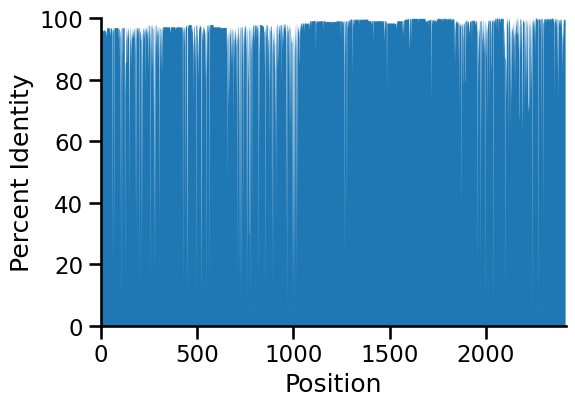

In [107]:
sns.set_context('talk')

plt.figure(figsize=(6, 4))

# Line plot
ax = sns.lineplot(data=percent_identities_df["percent_identity"], lw=0)

# Fill the area under the line
ax.fill_between(x=percent_identities_df.index, 
                 y1=percent_identities_df["percent_identity"], alpha=1)

ax.set_xlabel("Position")
ax.set_ylabel("Percent Identity")
ax.set_ylim(0, 100)
ax.set_xlim(0, 2414)
sns.despine()


plt.show()



# 2. Disorder

In [108]:
ref_seq = df[df["id"] == "REFERENCE"]["prot_seq"].iloc[0]
disord_pred = metapredict.predict_disorder(ref_seq)
disord_df = pd.DataFrame(disord_pred)
disord_df

,0
0,0.9919
1,0.9900
2,1.0000
3,0.9997
4,1.0000
...,...
2409,1.0000
2410,1.0000
2411,1.0000
2412,1.0000


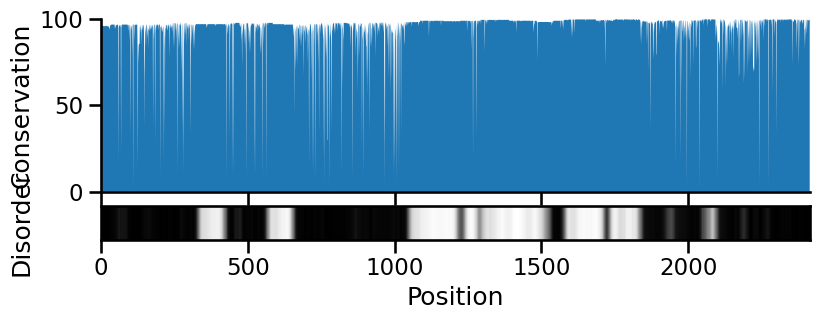

In [109]:

sns.set_context('talk')

fig, axs = plt.subplots(2, 1, figsize = (8, 3), sharex = True, height_ratios=[1, 0.2])

# Line plot
#sns.lineplot(data=percent_identities_df["percent_identity"], lw=0, ax =  axs[0])


# Perform LOWESS smoothing
# lowess = sm.nonparametric.lowess(percent_identities_df["percent_identity"], 
#                                  percent_identities_df.index, frac=0.025)  # Adjust `frac` for smoothing level
# Plot the smoothed trace
#sns.lineplot(x=lowess[:, 0], y=lowess[:, 1], color='navy', label='LOWESS Smoothed Trace', ax = axs[0])

# Fill the area under the line
axs[0].fill_between(x=percent_identities_df.index, 
                 y1=percent_identities_df["percent_identity"], alpha = 1)

axs[0].set_ylabel("Conservation")
axs[0].set_ylim(0, 100)
sns.despine(ax = axs[0])

#sns.lineplot(disord_df[0], ax = axs[1])
axs[1].imshow(disord_df[[0]].T, cmap='Grays', aspect='auto')
axs[1].set_ylabel("Disorder")
axs[1].set_yticks([])
#sns.despine(ax = axs[1], left = True)
#axs[1].set_ylim(0, 1.01)

axs[-1].set_xlim(0, 2414)
axs[-1].set_xlabel("Position")

fig.align_ylabels(axs)
plt.tight_layout(pad = 0)

plt.show()



# 3. Domain annotations

In [110]:
import matplotlib.patches as patches

def plot_rectangle(start, end, color, box_height, ax, y = 0, alpha = 0.7, name = ""):
    rectangle = patches.Rectangle((start, y), width=end - start, height=box_height, linewidth=1, edgecolor='none', facecolor=color, alpha=alpha)
    ax.add_patch(rectangle)
    ax.text(np.mean([start, end]), 0.5 * box_height, name, fontsize = 'small', va = 'center', ha = 'center')

(0.0, 2414.0)

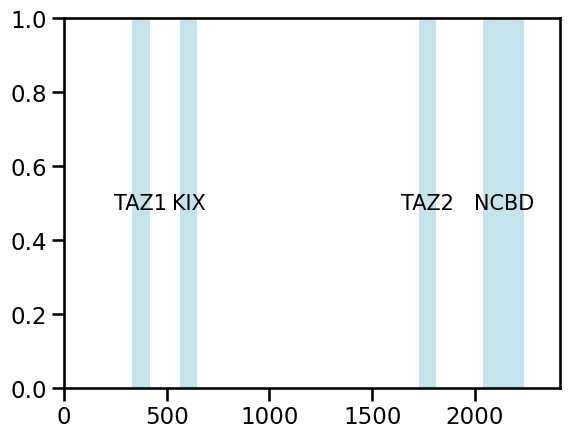

In [111]:
fig, ax = plt.subplots()
# According to uniprot
# TAZ1: 331-417
# KIX: 	566-645
# TAZ2: 1728-1809
# NCBD: 2041-2240?

plot_rectangle(331, 417, 'lightblue', 1, ax, name = 'TAZ1')
plot_rectangle(566, 645, 'lightblue', 1, ax, name = 'KIX')
plot_rectangle(1728, 1809, 'lightblue', 1, ax, name = 'TAZ2')
plot_rectangle(2041, 2240, 'lightblue', 1, ax, name = 'NCBD')

plt.xlim(0, 2414)

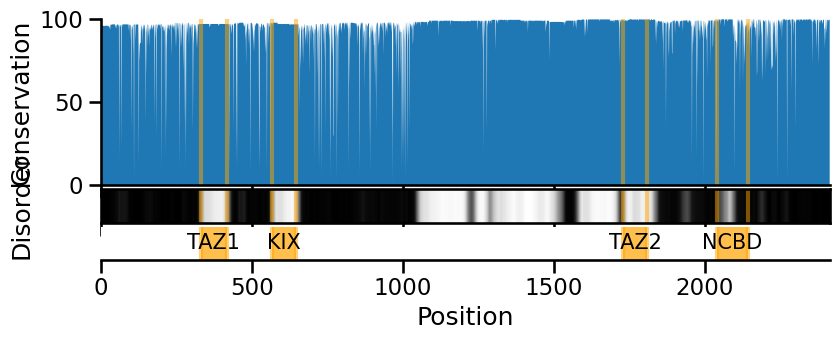

In [112]:

sns.set_context('talk')

fig, axs = plt.subplots(3, 1, figsize = (8, 3), sharex = True, height_ratios=[1, 0.2, 0.2])

# Line plot
#sns.lineplot(data=percent_identities_df["percent_identity"], lw=0, ax =  axs[0])


# Perform LOWESS smoothing
# lowess = sm.nonparametric.lowess(percent_identities_df["percent_identity"], 
#                                  percent_identities_df.index, frac=0.025)  # Adjust `frac` for smoothing level
# Plot the smoothed trace
#sns.lineplot(x=lowess[:, 0], y=lowess[:, 1], color='navy', label='LOWESS Smoothed Trace', ax = axs[0])

# Fill the area under the line
axs[0].fill_between(x=percent_identities_df.index, 
                 y1=percent_identities_df["percent_identity"], alpha = 1)

axs[0].set_ylabel("Conservation")
axs[0].set_ylim(0, 100)

sns.despine(ax = axs[0])

#sns.lineplot(disord_df[0], ax = axs[1])
axs[1].imshow(disord_df[[0]].T, cmap='Grays', aspect='auto')
axs[1].set_ylabel("Disorder")
axs[1].set_yticks([])

#sns.despine(ax = axs[1], left = True, bottom = True)
#axs[1].set_ylim(0, 1.01)

plot_rectangle(331, 417, 'orange', 1, axs[2], name = 'TAZ1')
plot_rectangle(566, 645, 'orange', 1, axs[2], name = 'KIX')
plot_rectangle(1728, 1809, 'orange', 1, axs[2], name = 'TAZ2')
plot_rectangle(2039, 2141, 'orange', 1, axs[2], name = 'NCBD') # using https://www.pnas.org/doi/10.1073/pnas.0702010104 2039–2141

for boundary in [331, 417, 566, 645, 1728, 1809, 2039, 2141]:
    for ax in [axs[0], axs[1], axs[2]]:
        ax.axvline(boundary, color = 'orange', alpha = 0.5, lw = 3)

axs[2].set_yticks([])
sns.despine(ax = axs[2], left = True)

plt.xlim(0, 2414)

axs[-1].set_xlim(0, 2414)
axs[-1].set_xlabel("Position")

fig.align_ylabels(axs)
plt.tight_layout(pad = -0.4)

plt.show()



# 4. Add NCPR

In [113]:
from localcider.sequenceParameters import SequenceParameters

SeqOb = SequenceParameters(ref_seq)
len(SeqOb.get_linear_NCPR(blobLen=5)[0])

2414

In [114]:
SeqOb.get_linear_NCPR(blobLen=5)[0]

array([1.000e+00, 2.000e+00, 3.000e+00, ..., 2.412e+03, 2.413e+03,
       2.414e+03])

<Axes: >

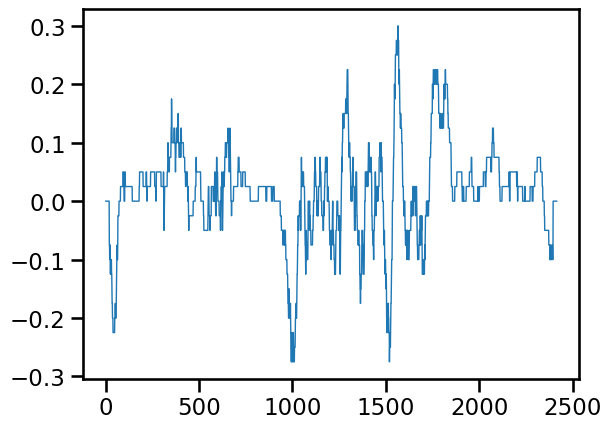

In [115]:
output = SeqOb.get_linear_NCPR(blobLen=40)
sns.lineplot(x = output[0], y = output[1], lw = 1)

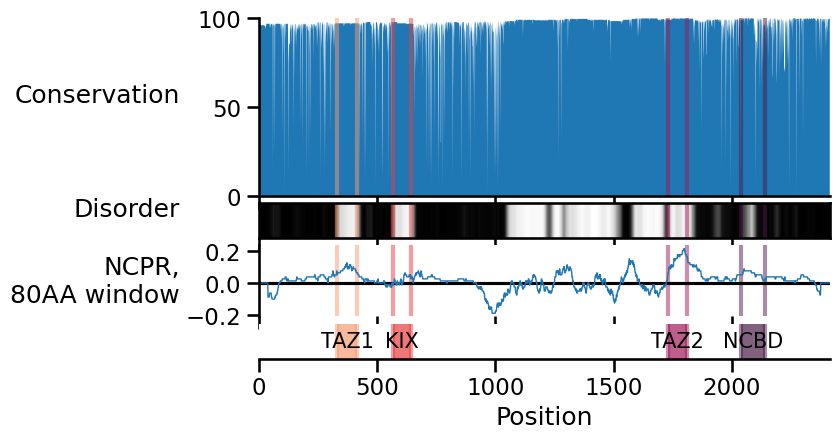

In [116]:

sns.set_context('talk')

fig, axs = plt.subplots(4, 1, figsize = (8, 4), sharex = True, height_ratios=[1, 0.2, 0.4, 0.2])

##CONSERVATION
# Line plot
#sns.lineplot(data=percent_identities_df["percent_identity"], lw=0, ax =  axs[0])


# Perform LOWESS smoothing
# lowess = sm.nonparametric.lowess(percent_identities_df["percent_identity"], 
#                                  percent_identities_df.index, frac=0.025)  # Adjust `frac` for smoothing level
# Plot the smoothed trace
#sns.lineplot(x=lowess[:, 0], y=lowess[:, 1], color='navy', label='LOWESS Smoothed Trace', ax = axs[0])

# Fill the area under the line
axs[0].fill_between(x=percent_identities_df.index, 
                 y1=percent_identities_df["percent_identity"], alpha = 1)

axs[0].set_ylabel("Conservation", rotation = 0, ha = 'right')
axs[0].set_ylim(0, 100)

sns.despine(ax = axs[0])

## DISORDER
#sns.lineplot(disord_df[0], ax = axs[1])
axs[1].imshow(disord_df[[0]].T, cmap='Grays', aspect='auto')
axs[1].set_ylabel("Disorder", rotation = 0, ha = 'right')
axs[1].set_yticks([])

#sns.despine(ax = axs[1], left = True, bottom = True)
#axs[1].set_ylim(0, 1.01)

## LABELS DOMAINS
palette = sns.color_palette('rocket_r', 4)

plot_rectangle(331, 417, palette[0], 1, axs[3], name = 'TAZ1')
plot_rectangle(566, 645, palette[1], 1, axs[3], name = 'KIX')
plot_rectangle(1728, 1809, palette[2], 1, axs[3], name = 'TAZ2')
plot_rectangle(2039, 2141, palette[3], 1, axs[3], name = 'NCBD') # using https://www.pnas.org/doi/10.1073/pnas.0702010104 2039–2141

i = 0

for boundary in [331, 417, 566, 645, 1728, 1809, 2039, 2141]:
    for ax in [axs[0], axs[1], axs[2], axs[3]]:
        ax.axvline(boundary, color = palette[i // 8], alpha = 0.5, lw = 3) 
        i += 1

axs[3].set_yticks([])
sns.despine(ax = axs[3], left = True)

## NCPR
output = SeqOb.get_linear_NCPR(blobLen=80)
axs[2].axhline(0, color = 'black')
sns.despine(bottom = True, ax = axs[2])
sns.lineplot(x = output[0], y = output[1], lw = 1, ax = axs[2])
axs[2].set_ylabel("NCPR,\n80AA window", rotation = 0, ha = 'right', va = 'center')

plt.xlim(0, 2414)

axs[-1].set_xlim(0, 2414)
axs[-1].set_xlabel("Position")

fig.align_ylabels(axs)
plt.tight_layout(pad = -0.4)

plt.show()



5. AlphaFold structure

In [117]:
# from Bio.PDB import PDBParser
# from Bio.PDB.DSSP import DSSP
# import pandas as pd
# import seaborn as sns
# import numpy as np
# import matplotlib.pyplot as plt
# import itertools
# import matplotlib.patches as patches


In [80]:
# HELPER FUNCTIONS:
# def plot_rectangle(start, end, color, box_height, ax, y = 0, alpha = 0.7):
#     if start != end:
#         rectangle = patches.Rectangle((start, y), width=end - start, height=box_height, linewidth=1, edgecolor='none', facecolor=color, alpha=alpha)
#         ax.add_patch(rectangle)
#     else:
#         ax.axvline(start, lw = 1, alpha = alpha, color = color)

def return_intervals(a):
    a = sorted(set(a))
    b = []
    for k, g in itertools.groupby(enumerate(a), 
        key=lambda t: t[1] - t[0]):
        g = list(g)
        b.append([g[0][1], g[-1][1]]) 
    
    return b

p = PDBParser()
structure = p.get_structure("P300", "../data/p300_AF-Q09472-F1-model_v4.pdb")
model = structure[0]
dssp = DSSP(model, "../data/p300_AF-Q09472-F1-model_v4.pdb")

pos = []
code = []

for i in range(len(list(dssp.keys()))):
    pos.append(i)
    a_key = list(dssp.keys())[i]
    code.append(dssp[a_key][2])

codes = pd.DataFrame({"pos" : pos, "code" : code})
codes["y"] = np.ones(len(codes))

codes

,pos,code,y
0,0,-,1.0
1,1,-,1.0
2,2,-,1.0
3,3,-,1.0
4,4,-,1.0
...,...,...,...
2409,2409,-,1.0
2410,2410,-,1.0
2411,2411,-,1.0
2412,2412,-,1.0


In [118]:
color_palette = {# Helices
                "G" : sns.color_palette('Blues')[-1],
                "H" : sns.color_palette('Blues')[-1],
                "I" : sns.color_palette('Blues')[-1],

                # Sheets
                "E" : sns.color_palette('Greens')[-1],
                "B" : sns.color_palette('Greens')[-1],

                # Poly proline helix
                "P" : sns.color_palette('Reds')[-1],

                # Other
                "T" : "white",
                "S" : "white",
                "-" : "white"}

[]

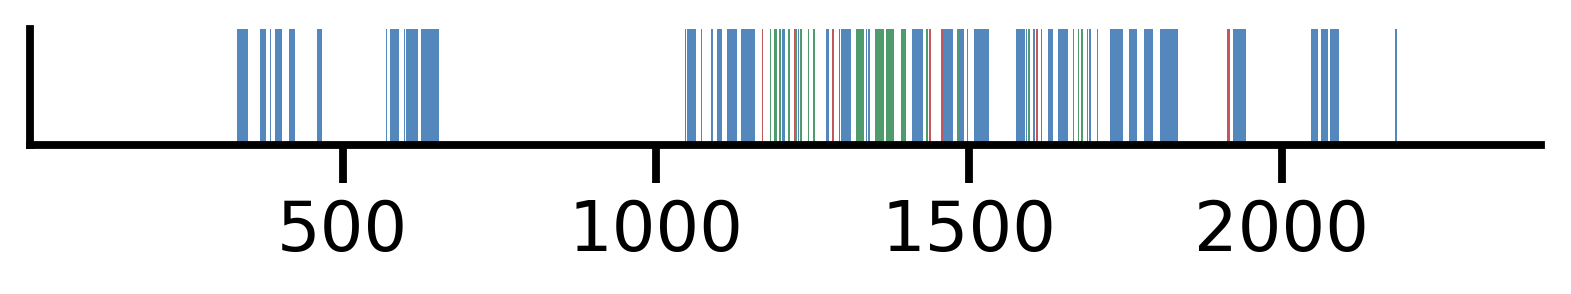

In [119]:
fig, ax = plt.subplots(figsize=(6.5,0.5), dpi = 300)


for code in set(codes["code"]):
    intervals =  return_intervals(codes[codes["code"] == code]["pos"])
    for s, e in intervals:
        #print(i)
        color = color_palette[code]
        plot_rectangle(s, e, color, 1, ax)
        ax.set_xlim(1, len(pos))       
i+=1

sns.despine()
ax.set_yticks([])
ax.set_yticklabels([])

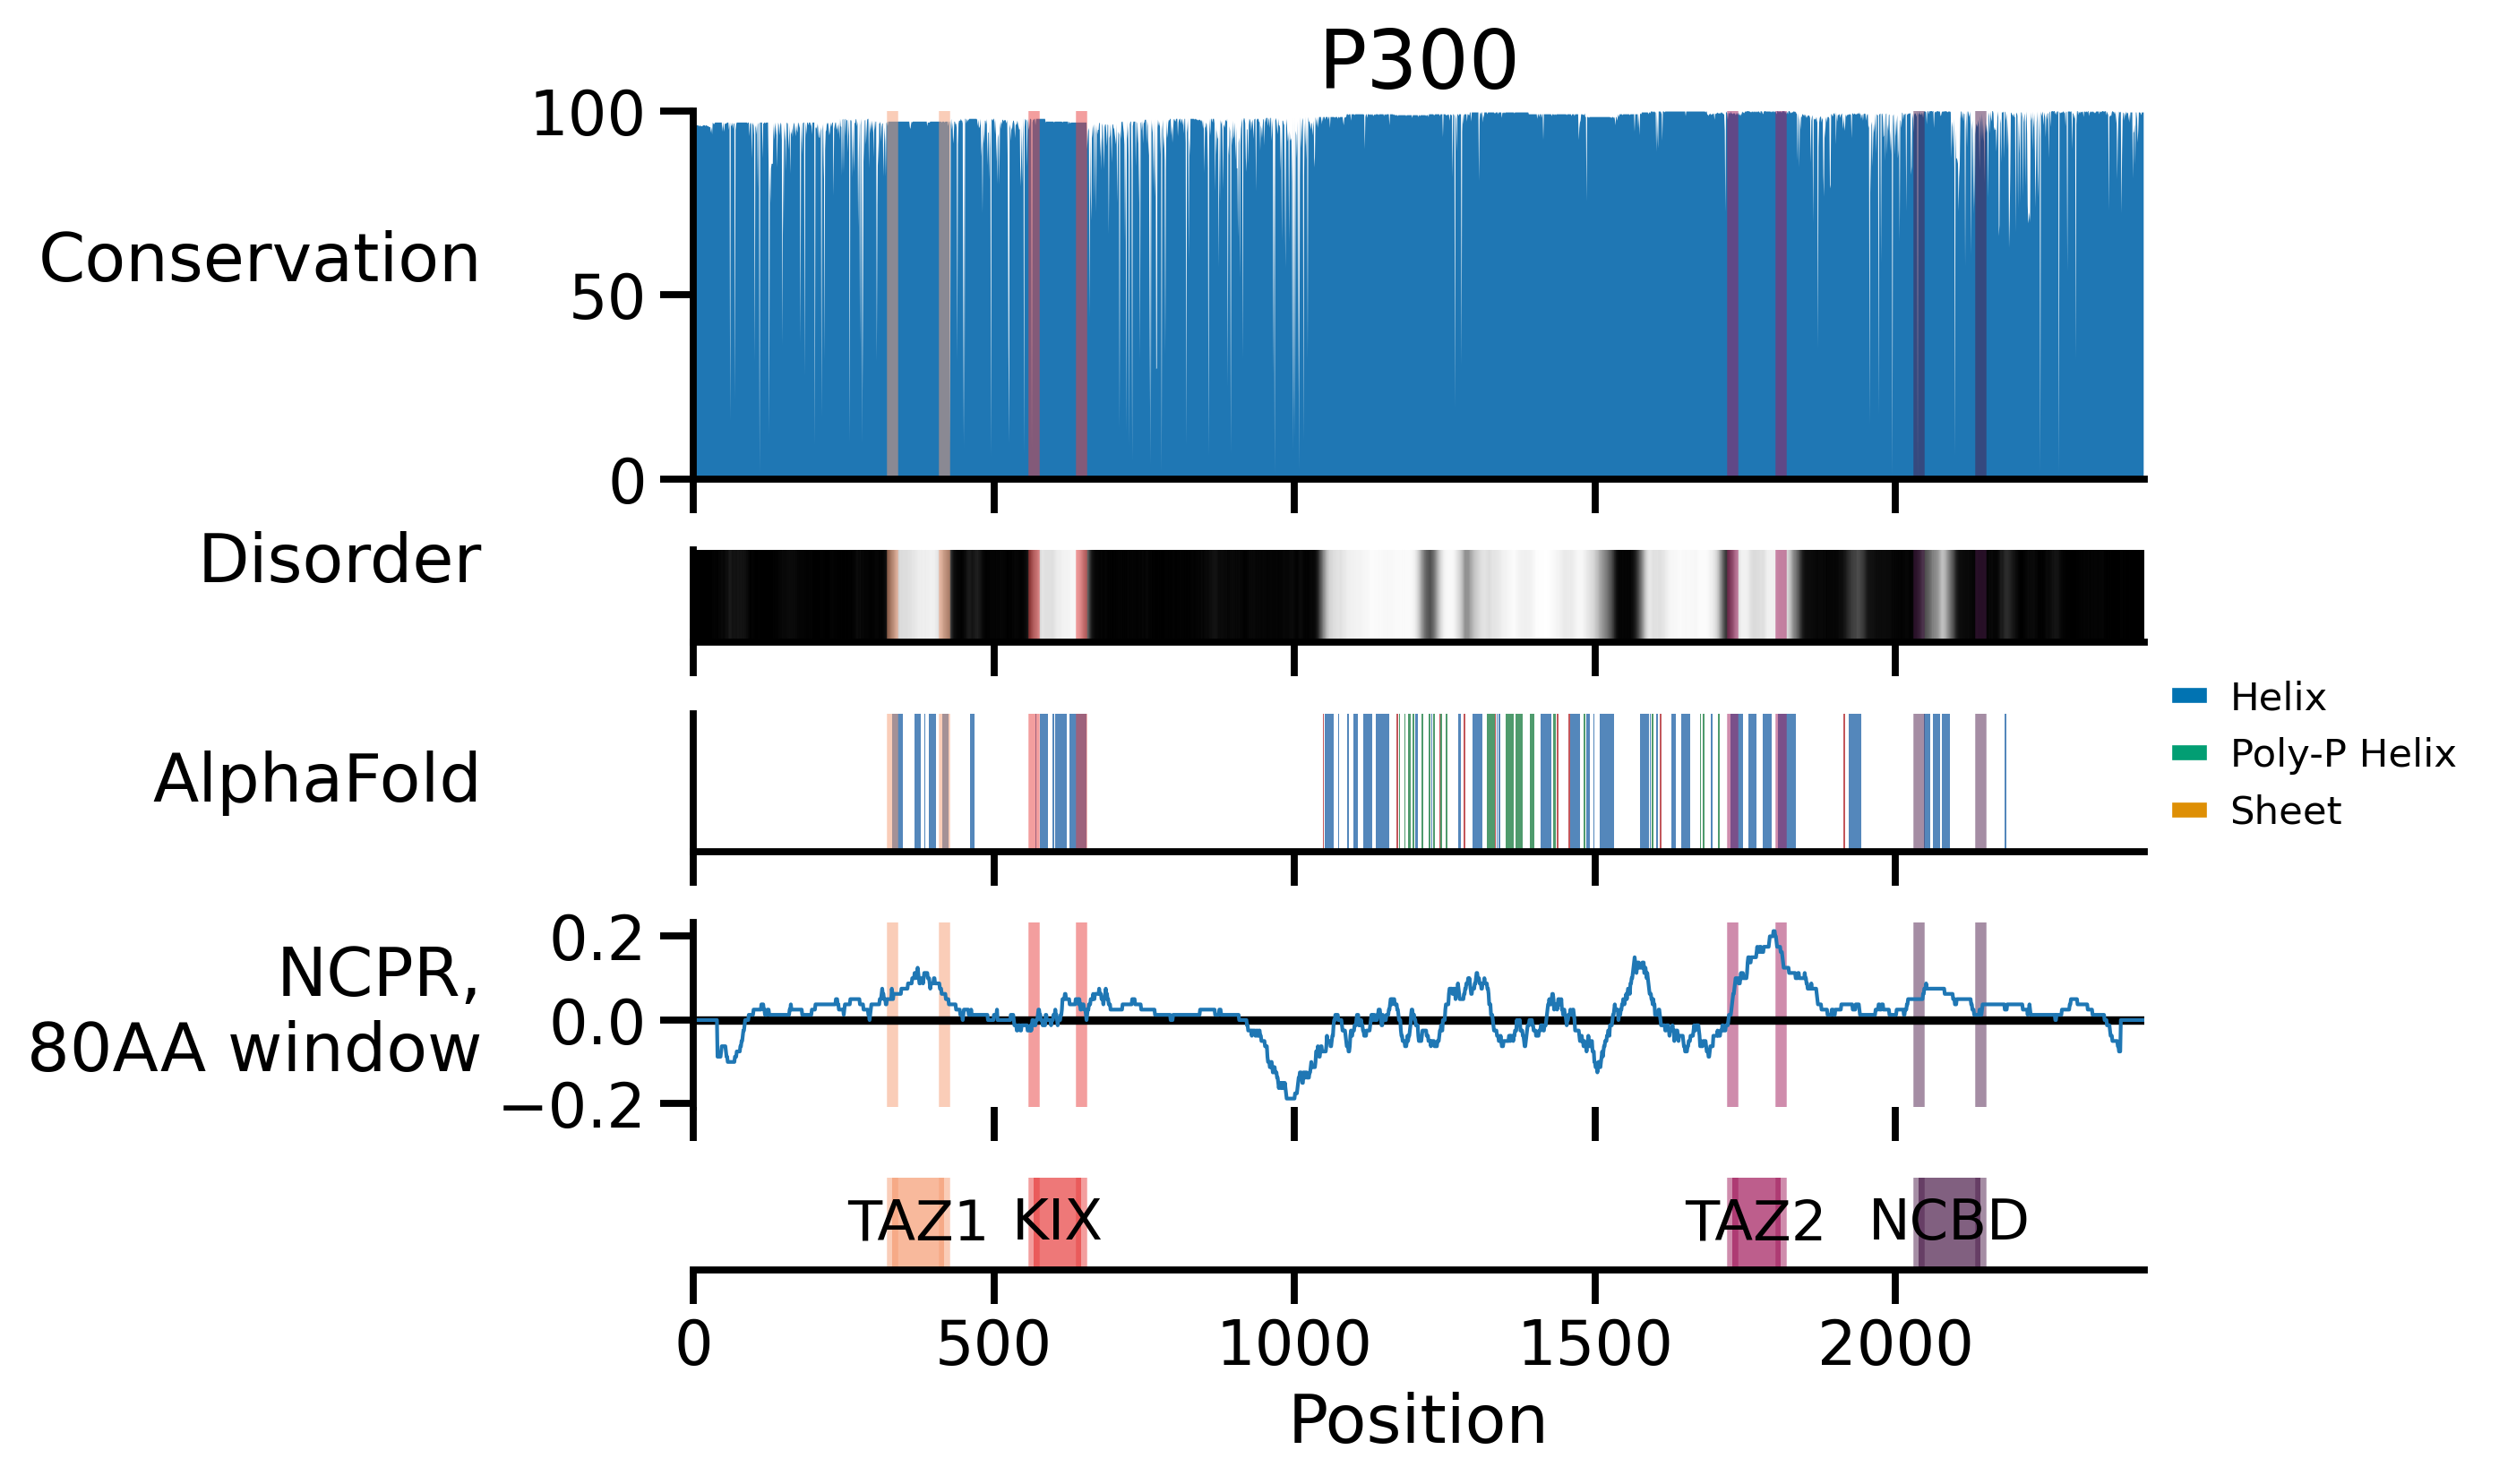

In [120]:

sns.set_context('talk')

fig, axs = plt.subplots(5, 1, figsize = (9, 5), sharex = True, height_ratios=[0.8, 0.2, 0.3, 0.4, 0.2], dpi = 300)

##CONSERVATION
# Line plot
#sns.lineplot(data=percent_identities_df["percent_identity"], lw=0, ax =  axs[0])


# Perform LOWESS smoothing
# lowess = sm.nonparametric.lowess(percent_identities_df["percent_identity"], 
#                                  percent_identities_df.index, frac=0.025)  # Adjust `frac` for smoothing level
# Plot the smoothed trace
#sns.lineplot(x=lowess[:, 0], y=lowess[:, 1], color='navy', label='LOWESS Smoothed Trace', ax = axs[0])

# Fill the area under the line
axs[0].fill_between(x=percent_identities_df.index, 
                 y1=percent_identities_df["percent_identity"], alpha = 1)

axs[0].set_ylabel("Conservation", rotation = 0, ha = 'right')
axs[0].set_ylim(0, 100)

sns.despine(ax = axs[0])

## DISORDER
#sns.lineplot(disord_df[0], ax = axs[1])
axs[1].imshow(disord_df[[0]].T, cmap='Grays', aspect='auto')
axs[1].set_ylabel("Disorder", rotation = 0, ha = 'right')
axs[1].set_yticks([])

# AF

ax = axs[2]
sns.despine(ax = axs[2], left = True)

for code in set(codes["code"]):
    intervals =  return_intervals(codes[codes["code"] == code]["pos"])
    for s, e in intervals:
        #print(i)
        color = color_palette[code]
        plot_rectangle(s, e, color, 1, ax)
        ax.set_xlim(1, len(pos))       
i+=1

axs[2].set_ylabel("AlphaFold", rotation = 0, va = 'center', ha = 'right')

sns.despine()
ax.set_yticks([])
ax.set_yticklabels([])

#sns.despine(ax = axs[1], left = True, bottom = True)
#axs[1].set_ylim(0, 1.01)

from matplotlib.lines import Line2D

def add_custom_legend(color_dict, ax, bbox_to_anchor = (1, 1)):
    custom_lines = [Line2D([0], [0], markersize=2, color=c, lw=4) for c in color_dict.values()]
    ax.legend(custom_lines, color_dict.keys(), bbox_to_anchor = bbox_to_anchor, frameon = False, fontsize = 'xx-small', handlelength = 0.5)

add_custom_legend({"Helix" : sns.color_palette('colorblind')[0],
                    "Poly-P Helix": sns.color_palette('colorblind')[2],
                    "Sheet" : sns.color_palette('colorblind')[1]}, ax = axs[2], bbox_to_anchor = (1, 1.5))

## LABELS DOMAINS
palette = sns.color_palette('rocket_r', 4)

plot_rectangle(331, 417, palette[0], 1, axs[4], name = 'TAZ1')
plot_rectangle(566, 645, palette[1], 1, axs[4], name = 'KIX')
plot_rectangle(1728, 1809, palette[2], 1, axs[4], name = 'TAZ2')
plot_rectangle(2039, 2141, palette[3], 1, axs[4], name = 'NCBD') # using https://www.pnas.org/doi/10.1073/pnas.0702010104 2039–2141

i = 0

for boundary in [331, 417, 566, 645, 1728, 1809, 2039, 2141]:
    for ax in [axs[0], axs[1], axs[2], axs[3], axs[4]]:
        ax.axvline(boundary, color = palette[i // 10], alpha = 0.5, lw = 3) 
        i += 1

axs[4].set_yticks([])
sns.despine(ax = axs[4], left = True)



## NCPR
output = SeqOb.get_linear_NCPR(blobLen=80)
axs[3].axhline(0, color = 'black')
sns.despine(bottom = True, ax = axs[3])
sns.lineplot(x = output[0], y = output[1], lw = 1, ax = axs[3])
axs[3].set_ylabel("NCPR,\n80AA window", rotation = 0, ha = 'right', va = 'center')

plt.xlim(0, 2414)

axs[-1].set_xlim(0, 2414)
axs[-1].set_xlabel("Position")

fig.align_ylabels(axs)
plt.tight_layout(pad = -0.2)


axs[0].set_title("P300", ha = 'center', fontsize = 'large')

plt.show()




# Adding 100 vertebrates CDS conservation too

In [145]:
p300_cds_coords = pd.read_csv("../data/ep300_mart_export.txt", sep = "\t")
p300_cds_coords.drop_duplicates()

,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Exon region start (bp),Exon region end (bp),cDNA coding start,cDNA coding end,Genomic coding start,Genomic coding end,CDS start,CDS end,Strand,Chromosome/scaffold name
0,ENSG00000100393,ENSG00000100393.16,ENST00000715703,ENST00000715703.1,41092510,41093098,496.0,589.0,41093005.0,41093098.0,1.0,94.0,1,22
1,ENSG00000100393,ENSG00000100393.16,ENST00000715703,ENST00000715703.1,41117187,41117821,590.0,1224.0,41117187.0,41117821.0,95.0,729.0,1,22
2,ENSG00000100393,ENSG00000100393.16,ENST00000715703,ENST00000715703.1,41125864,41126040,1225.0,1401.0,41125864.0,41126040.0,730.0,906.0,1,22
3,ENSG00000100393,ENSG00000100393.16,ENST00000715703,ENST00000715703.1,41127487,41127748,1402.0,1663.0,41127487.0,41127748.0,907.0,1168.0,1,22
4,ENSG00000100393,ENSG00000100393.16,ENST00000715703,ENST00000715703.1,41129890,41130003,1664.0,1777.0,41129890.0,41130003.0,1169.0,1282.0,1,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,ENSG00000100393,ENSG00000100393.16,ENST00000635584,ENST00000635584.1,41168721,41168867,NaN,NaN,NaN,NaN,NaN,NaN,1,22
161,ENSG00000100393,ENSG00000100393.16,ENST00000635584,ENST00000635584.1,41162727,41162779,NaN,NaN,NaN,NaN,NaN,NaN,1,22
162,ENSG00000100393,ENSG00000100393.16,ENST00000635584,ENST00000635584.1,41169283,41169329,NaN,NaN,NaN,NaN,NaN,NaN,1,22
163,ENSG00000100393,ENSG00000100393.16,ENST00000635083,ENST00000635083.1,41176059,41176528,NaN,NaN,NaN,NaN,NaN,NaN,1,22


In [146]:
p300_cds_coords["Transcript stable ID"].unique()
# Will use ENST00000263253 because it matches to uniprot based on transcript table at https://useast.ensembl.org/Homo_sapiens/Gene/Summary?g=ENSG00000100393;r=22:41092510-41180077

array(['ENST00000715703', 'ENST00000263253', 'ENST00000703544',
       'ENST00000674155', 'ENST00000637592', 'ENST00000703545',
       'ENST00000634787', 'ENST00000634860', 'ENST00000634690',
       'ENST00000635538', 'ENST00000634422', 'ENST00000635691',
       'ENST00000635552', 'ENST00000635584', 'ENST00000635083'],
      dtype=object)

In [148]:
p300_cds_coords_enst = p300_cds_coords[p300_cds_coords["Transcript stable ID"] == "ENST00000263253"]
p300_cds_coords_enst["Chromosome/scaffold name"] = "chr" + p300_cds_coords_enst["Chromosome/scaffold name"].astype(str)
p300_cds_coords_enst["Genomic coding start"] = p300_cds_coords_enst["Genomic coding start"].astype(int)
p300_cds_coords_enst["Genomic coding end"] = p300_cds_coords_enst["Genomic coding end"].astype(int)
p300_cds_coords_enst[["Chromosome/scaffold name", "Genomic coding start", "Genomic coding end"]].to_csv("../output/ep300.bed", index = None, header = None, sep = "\t")

In [206]:
verteb_phyloP  = []

df = pd.read_csv("../output/ep300_100_vert", 
                delim_whitespace=True, 
                comment='#', 
                header=None, 
            skiprows = 1,
                names=['Position', 'Value'])
df = df.reset_index()
#Extract chromosome number
df["chr"] = df["Position"].str.split("chr").str[-1]

# update chromosome number
most_recent_chr = ""
for i in df.index:
    row = df.loc[i]
    if row["index"] == "variableStep":
        most_recent_chr = row["chr"]
    else:
        df.at[i, "chr"] = most_recent_chr
df = df[df["index"] != "variableStep"].drop(columns = "Value")
df

,index,Position,chr
1,41117188,4.79958,22
2,41117189,7.61311,22
3,41117190,7.61311,22
4,41117191,2.50708,22
5,41117192,9.593,22
...,...,...,...
7240,41178952,3.41813,22
7241,41178953,4.91809,22
7242,41178954,6.69931,22
7243,41178955,3.51187,22


In [214]:
df = df.sort_values(by = "index")
df["Position"] = df["Position"].astype(float)
df["prot_pos"] = df.index / 3
df = df.reset_index(drop = True)
df

,index,Position,chr,prot_pos
0,41093006,6.86039,22,0.000000
1,41093007,8.65600,22,0.333333
2,41093008,8.65600,22,0.666667
3,41093009,6.76064,22,1.000000
4,41093010,6.76064,22,1.333333
...,...,...,...,...
7209,41178952,3.41813,22,2403.000000
7210,41178953,4.91809,22,2403.333333
7211,41178954,6.69931,22,2403.666667
7212,41178955,3.51187,22,2404.000000


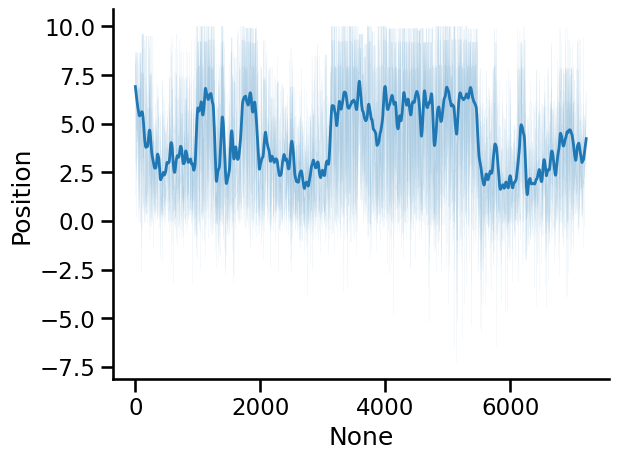

In [218]:
from statsmodels.nonparametric.smoothers_lowess import lowess

color = sns.color_palette('tab10')[0]

# Plot the original data
sns.lineplot(x=df.index, y=df["Position"], linewidth=0.05, color=color, alpha = 0.5)

# Perform LOWESS smoothing
smoothed = lowess(df["Position"], df.index, frac=0.01)

# Plot the smoothed line
sns.lineplot(x=smoothed[:, 0], y=smoothed[:, 1], linewidth=2, color=color)

sns.despine()

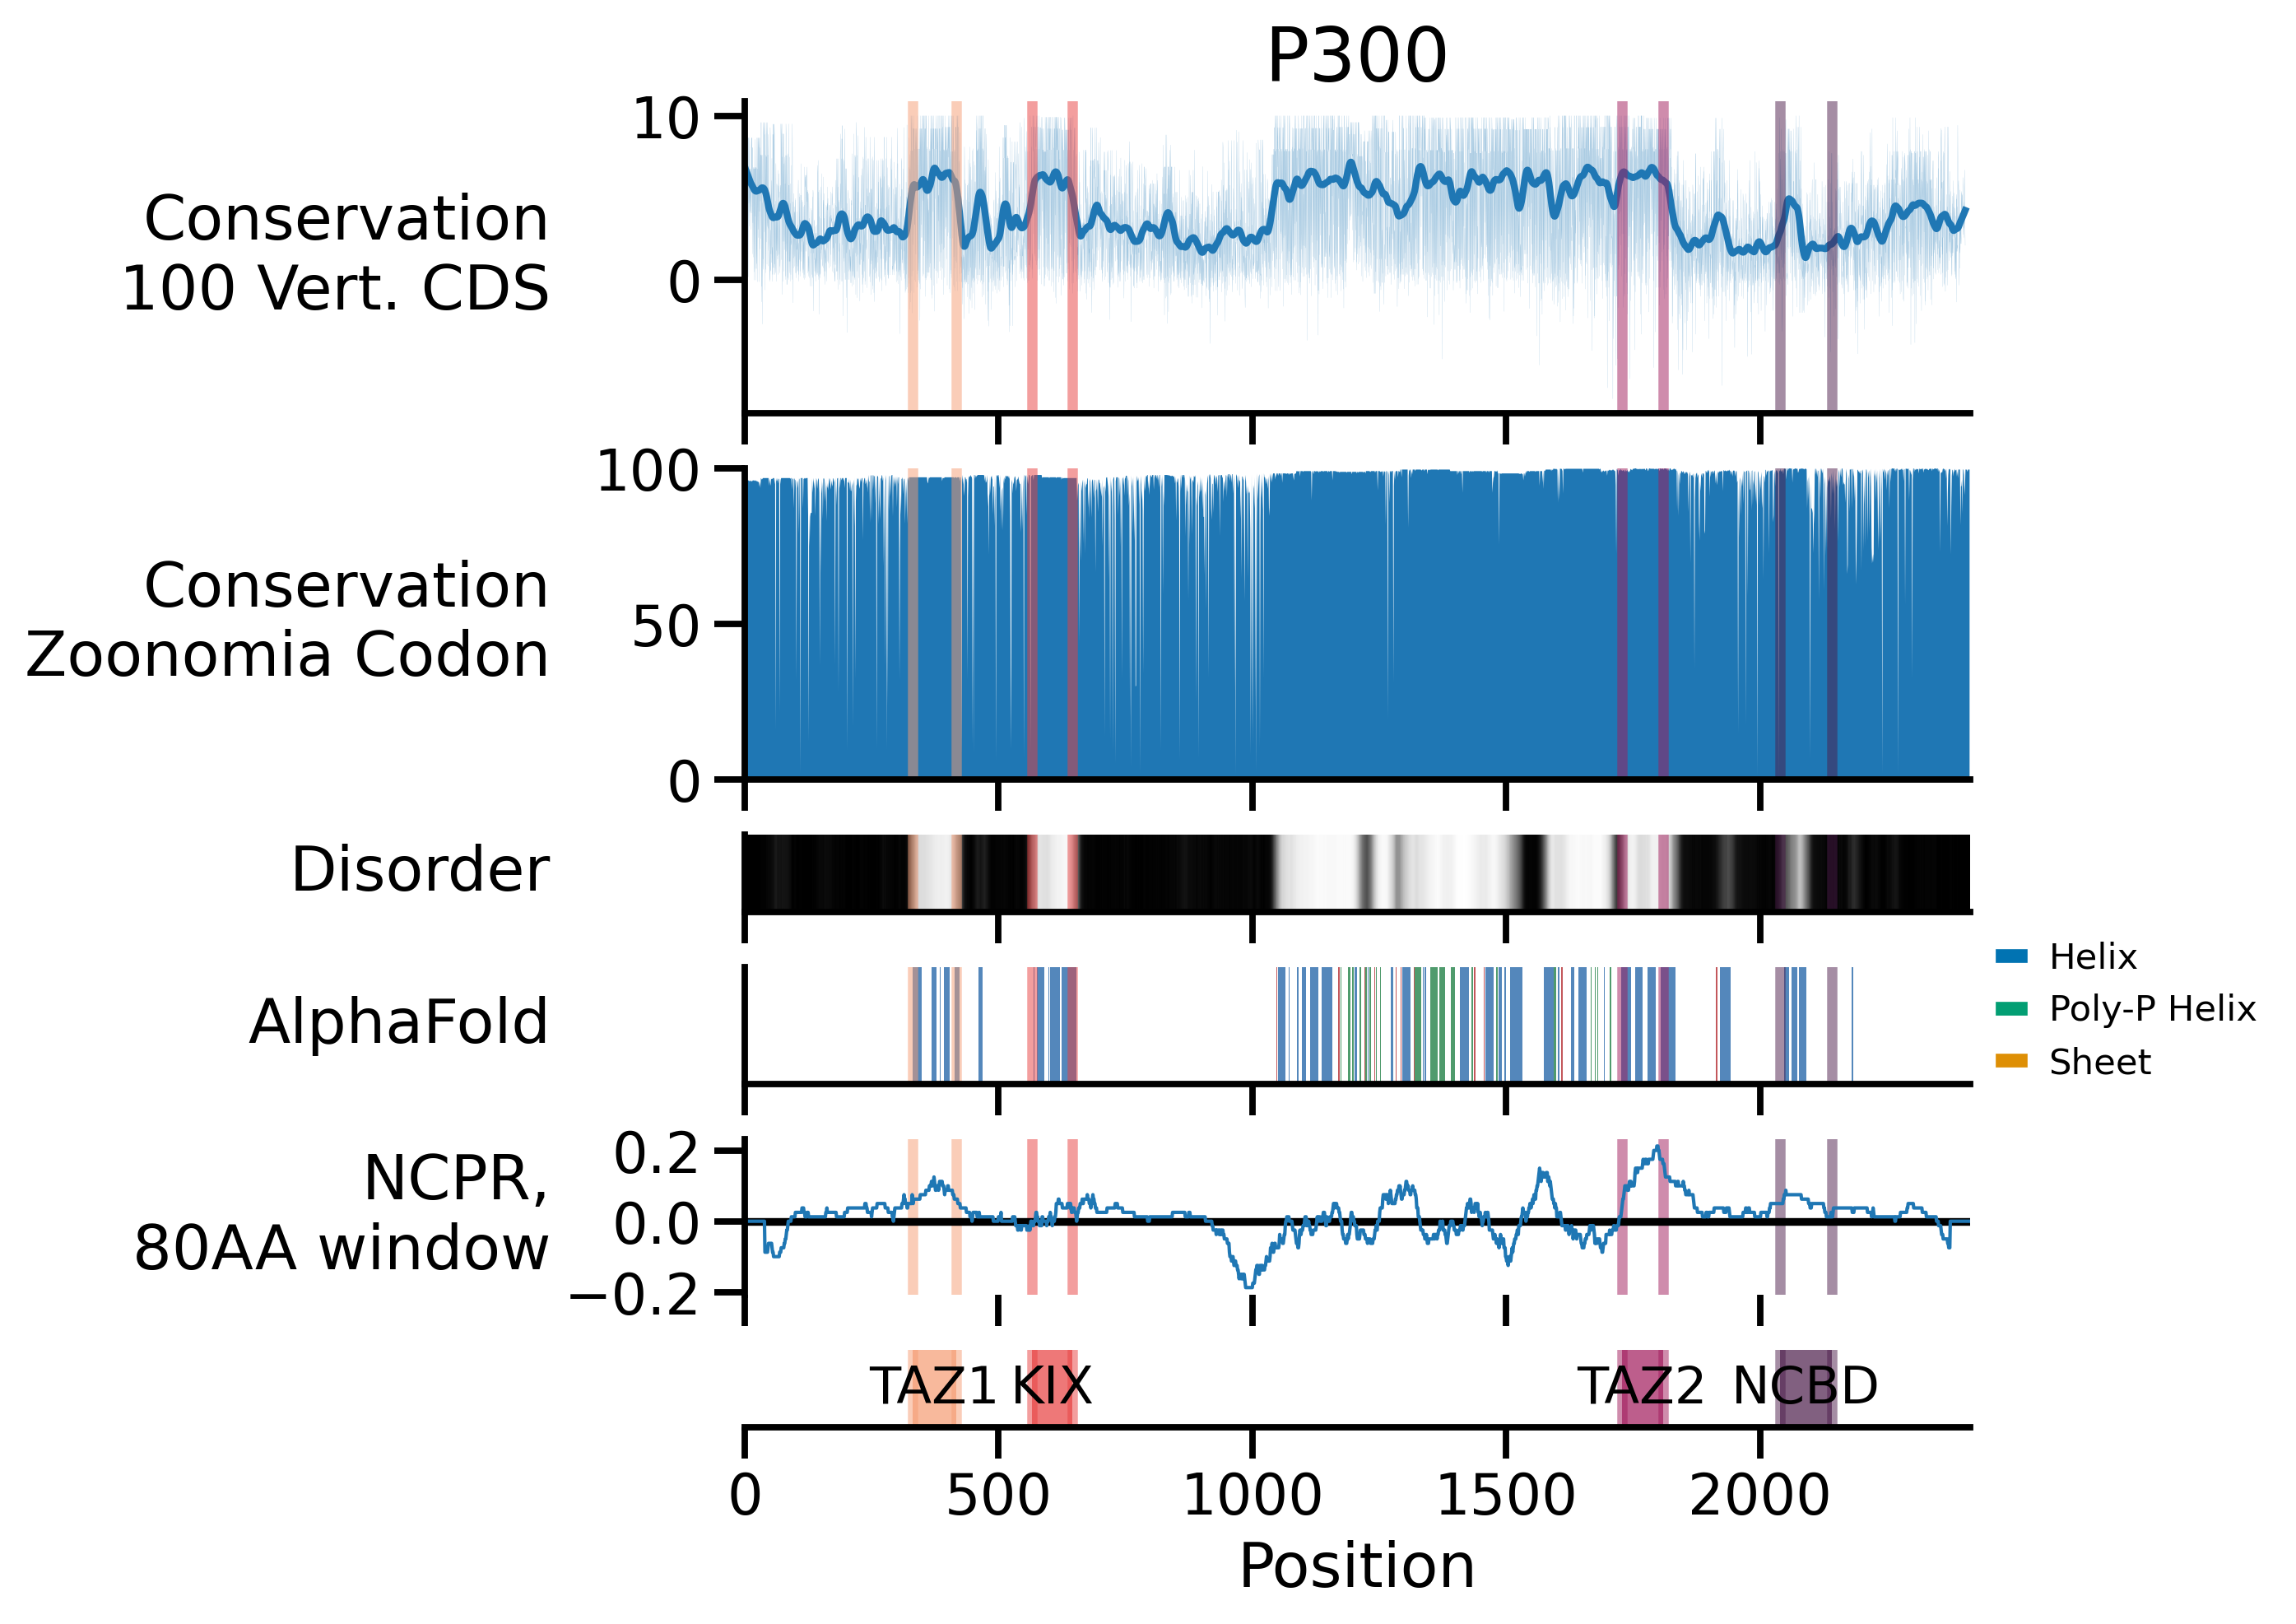

In [227]:
sns.set_context('talk')

fig, axs = plt.subplots(6, 1, figsize=(9, 6), sharex=True, height_ratios=[0.8, 0.8, 0.2, 0.3, 0.4, 0.2], dpi=300)

## NEW FIRST PLOT
color = sns.color_palette('tab10')[0]
# Plot the original data
sns.lineplot(x=df["prot_pos"], y=df["Position"], linewidth=0.05, color=color, alpha=0.5, ax=axs[0])
# Perform LOWESS smoothing
smoothed = lowess(df["Position"], df["prot_pos"], frac=0.01)

# Plot the smoothed line
sns.lineplot(x=smoothed[:, 0], y=smoothed[:, 1], linewidth=2, color=color, ax=axs[0])
sns.despine(ax=axs[0])
axs[0].set_ylabel("Conservation\n100 Vert. CDS", rotation=0, ha='right', va='center')

## CONSERVATION
axs[1].fill_between(x=percent_identities_df.index, 
                    y1=percent_identities_df["percent_identity"], alpha=1)
axs[1].set_ylabel("Conservation\nZoonomia Codon", rotation=0, ha='right', va='center')
axs[1].set_ylim(0, 100)
sns.despine(ax=axs[1])

## DISORDER
axs[2].imshow(disord_df[[0]].T, cmap='Grays', aspect='auto')
axs[2].set_ylabel("Disorder", rotation=0, ha='right', va='center')
axs[2].set_yticks([])

## AF
ax = axs[3]
sns.despine(ax=axs[3], left=True)
for code in set(codes["code"]):
    intervals = return_intervals(codes[codes["code"] == code]["pos"])
    for s, e in intervals:
        color = color_palette[code]
        plot_rectangle(s, e, color, 1, ax)
        ax.set_xlim(1, len(pos))
axs[3].set_ylabel("AlphaFold", rotation=0, va='center', ha='right')
sns.despine()
ax.set_yticks([])
ax.set_yticklabels([])

add_custom_legend({"Helix": sns.color_palette('colorblind')[0],
                   "Poly-P Helix": sns.color_palette('colorblind')[2],
                   "Sheet": sns.color_palette('colorblind')[1]}, ax=axs[3], bbox_to_anchor=(1, 1.5))

## LABELS DOMAINS
palette = sns.color_palette('rocket_r', 4)
plot_rectangle(331, 417, palette[0], 1, axs[5], name='TAZ1')
plot_rectangle(566, 645, palette[1], 1, axs[5], name='KIX')
plot_rectangle(1728, 1809, palette[2], 1, axs[5], name='TAZ2')
plot_rectangle(2039, 2141, palette[3], 1, axs[5], name='NCBD')

i = 0
for boundary in [331, 417, 566, 645, 1728, 1809, 2039, 2141]:
    for ax in axs:
        ax.axvline(boundary, color=palette[i // 2], alpha=0.5, lw=3)
    i += 1
        
axs[5].set_yticks([])
sns.despine(ax=axs[5], left=True)

## NCPR
output = SeqOb.get_linear_NCPR(blobLen=80)
axs[4].axhline(0, color='black')
sns.despine(bottom=True, ax=axs[4])
sns.lineplot(x=output[0], y=output[1], lw=1, ax=axs[4])
axs[4].set_ylabel("NCPR,\n80AA window", rotation=0, ha='right', va='center')

plt.xlim(0, 2414)
axs[-1].set_xlim(0, 2414)
axs[-1].set_xlabel("Position")

fig.align_ylabels(axs)
plt.tight_layout(pad=-0.2)

axs[0].set_title("P300", ha='center', fontsize='large')

plt.show()


# Now, looking at the ADs which associate with TAZ1 vs TAZ2

## 1. Interaction info

In [84]:
# Information on identifiers mapping to Gene, start, end 
# Only looking within TFs
variant_ID_to_seq = pd.read_excel("../data/media-12.xlsx", sheet_name = "Supplementary Table 1")
variant_ID_to_seq["Variant_ID"] = variant_ID_to_seq["Name"].str.split(";").str[2:4].str.join(";")
variant_ID_to_seq = variant_ID_to_seq[variant_ID_to_seq["Name"].str.contains("TFTiles")]
variant_ID_to_seq["Start"] = variant_ID_to_seq["Name"].str.extract(r'.*;.*;.*;(\d+);\d+;').astype(int)
variant_ID_to_seq["End"] = variant_ID_to_seq["Name"].str.extract(r".*;.*;.*;\d+;(\d+);").astype(int)
variant_ID_to_seq["Gene"] = variant_ID_to_seq["Variant_ID"].str.split(";").str[0]
variant_ID_to_seq

,Name,DNA Sequence,Variant_ID,Start,End,Gene
0,TFTiles;ENSG00000008197;TFAP2D;0;1;80;583Lambert,TCGACAATGGTATGGCTGgCGTCTCGctccTCAACTACATTTCCAG...,TFAP2D;0,1,80,TFAP2D
1,TFTiles;ENSG00000008197;TFAP2D;2;21;100;583Lam...,TCGACAATGGTATGGCTGgCGTCTCGctccTACAGGTTGATGCAAC...,TFAP2D;2,21,100,TFAP2D
2,TFTiles;ENSG00000008197;TFAP2D;33;331;410;583L...,TCGACAATGGTATGGCTGgCGTCTCGctccACAGCCAGGAAAAAGA...,TFAP2D;33,331,410,TFAP2D
3,TFTiles;ENSG00000050344;NFE2L3;25;251;330;583L...,TCGACAATGGTATGGCTGgCGTCTCGctccCACCTGAATGGGACTG...,NFE2L3;25,251,330,NFE2L3
4,TFTiles;ENSG00000050344;NFE2L3;26;261;340;583L...,TCGACAATGGTATGGCTGgCGTCTCGctccCTGGAGGACCTGTTCC...,NFE2L3;26,261,340,NFE2L3
...,...,...,...,...,...,...
693,TFTiles;ENSG00000166454;ATMIN;57;571;650;ZF,TCGACAATGGTATGGCTGgCGTCTCGctccAATAGCATGCTTCCTT...,ATMIN;57,571,650,ATMIN
694,TFTiles;ENSG00000166454;ATMIN;60;601;680;ZF,TCGACAATGGTATGGCTGgCGTCTCGctccCTGCCCGCTCAGACAT...,ATMIN;60,601,680,ATMIN
695,TFTiles;ENSG00000166454;ATMIN;61;611;690;ZF,TCGACAATGGTATGGCTGgCGTCTCGctccCTTCTGTCAGACACAA...,ATMIN;61,611,690,ATMIN
696,TFTiles;ENSG00000166454;ATMIN;62;621;700;ZF,TCGACAATGGTATGGCTGgCGTCTCGctccACCCAGCTCCCGTCTG...,ATMIN;62,621,700,ATMIN


In [85]:
interactions = pd.read_excel("../data/media-12.xlsx", sheet_name = "Supplementary Table 4")
interactions

,Variant_ID,BRD7,P300,P300 KIX,P300 NCBD,P300 TAZ1,P300 TAZ2,TFIID TAF12,PCAF TAF6L,P300 top binder,...,P300 NCBD binder,BRD7 binder,TAF6L binder,TFIID TAF12 binder,Domain Sequence,NCPR,Q Count,S Count,P Count,DE Count
0,AKAP8;0,24489.173719,8021.013261,76459.129783,73699.021811,53489.147091,16974.320686,73676.163467,10811.817848,0,...,0,0,0,0,DQGYGGYGAWSAGPANTQGAYGTGVASWQGYENYNYYGAQNTSVTT...,-0.037500,4,6,3,4
1,APBB1;22,24489.173719,2600.794744,100569.655867,69764.004568,33022.563280,15400.137470,73676.163467,10811.817848,0,...,0,0,0,0,DSSWATLSQGSPSYGSPEDTDSFWNPNAFETDSDLPAGWMRVQDTS...,-0.112500,6,14,9,11
2,ARGFX;14,23824.359918,3190.649631,100569.655867,64039.756865,53060.906744,46358.971168,73676.163467,10811.817848,0,...,0,0,0,0,AKQRNQILPSKKNVPTSPRTSPSPYAFSPVISDFYSSLPSQPLDPS...,0.000000,6,15,10,6
3,ARGFX;23,24489.173719,6608.372261,100569.655867,68364.846393,44601.431619,28685.815331,73676.163467,10811.817848,0,...,0,0,0,0,ELYNLPDENEISSSSFHCLYQYLSPTKYQVGGQGSSLSIFAGPAVG...,-0.075000,6,13,5,8
4,ARNTL2;54,24489.173719,9083.551952,100569.655867,71227.089950,53489.147091,13621.284705,73676.163467,10811.817848,0,...,0,0,0,0,TGLMKDTHTVNCRSMSNKELFPPSPSEMGELEATRQNQSTVAVHSH...,-0.125000,3,7,4,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,ZNF200;6,24489.173719,18465.692917,100569.655867,88602.083025,43799.284438,46358.971168,73676.163467,10811.817848,0,...,0,0,0,0,PSQKVKETLVIMKDVSSSLQNRVHPRPLVKLLPKGVQKEQETVSLY...,-0.025000,7,7,6,11
204,ZNF469;83,5584.305175,NaN,NaN,73198.858418,53489.147091,16814.779138,73676.163467,10811.817848,0,...,0,1,0,0,LDMEDDAKLDSLITEALNGMEYQSDNPEIDSSFIDVFADEEPSGPR...,-0.137500,2,9,13,16
205,ZNF644;90,24489.173719,6828.651128,100569.655867,88602.083025,48048.839227,21319.716791,73676.163467,10811.817848,0,...,0,0,0,0,PGENATLSYDQNDGFYFEYYEDTGSNNFLHEIHDPQHLETADASLS...,-0.125000,2,9,4,13
206,ZNF687;0,24489.173719,18138.822920,100569.655867,88602.083025,51253.579409,46358.971168,73676.163467,10811.817848,0,...,0,0,0,0,GDMKTPDFDDLLAAFDIPDIDANEAIHSGPEENEGPGGPGKPEPGV...,-0.200000,1,6,12,18


In [86]:
interactions.columns

Index(['Variant_ID', 'BRD7', 'P300', 'P300 KIX', 'P300 NCBD', 'P300 TAZ1',
       'P300 TAZ2', 'TFIID TAF12', 'PCAF TAF6L', 'P300 top binder',
       'P300 TAZ2 top binder', 'P300 KIX top binder', 'P300 TAZ1 top binder',
       'P300 NCBD top binder', 'BRD7 top binder', 'TFIID TAF12 top binder',
       'TAF6L top binder', 'P300 binder', 'P300 KIX binder',
       'P300 TAZ2 binder', 'P300 TAZ1 binder', 'P300 NCBD binder',
       'BRD7 binder', 'TAF6L binder', 'TFIID TAF12 binder', 'Domain Sequence',
       'NCPR', 'Q Count', 'S Count', 'P Count', 'DE Count'],
      dtype='object')

In [376]:
sum(interactions["P300 TAZ1 binder"].dropna())

37

In [377]:
sum(interactions["P300 TAZ2 binder"].dropna())

90

In [444]:
# Saving relevant info 
TF_interactions = pd.merge(variant_ID_to_seq[["Variant_ID", "Start", "End", "Gene"]], interactions[["Variant_ID", 'P300 KIX binder',
       'P300 TAZ2 binder', 'P300 TAZ1 binder', 'P300 NCBD binder']])
TF_interactions

,Variant_ID,Start,End,Gene,P300 KIX binder,P300 TAZ2 binder,P300 TAZ1 binder,P300 NCBD binder
0,NFE2L3;33,331,410,NFE2L3,0,1,1,1
1,CREB3L3;0,1,80,CREB3L3,1,1,1,0
2,MYBL2;39,391,470,MYBL2,0,1,0,0
3,MYBL2;41,411,490,MYBL2,0,1,0,0
4,RELB;45,451,530,RELB,0,0,1,1
...,...,...,...,...,...,...,...,...
135,TRAFD1;23,231,310,TRAFD1,0,1,0,0
136,ZNF200;6,61,140,ZNF200,0,0,0,0
137,ZNF469;83,831,910,ZNF469,0,1,0,0
138,EGR4;19,191,270,EGR4,0,0,0,0


## 2. Getting % identities

In [445]:
folder_path = "../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/"
alignment_paths = glob.glob(folder_path + "*")

TF_interactions_conservation = []

for gene in TF_interactions["Gene"]:
    if folder_path + gene not in alignment_paths:
        print(gene)
    else:
        gene_df = pd.read_csv(folder_path + gene)
        gene_df["Gene"] = gene
        gene_df = gene_df.rename(columns = {"Unnamed: 0" : "loc"})
        TF_interactions_conservation.append(gene_df)

TF_interactions_conservation = pd.concat(TF_interactions_conservation)
TF_interactions_conservation

HLF
HLF
TEF
ERG
FOS
MYB
MYB
MYB
TET2
TET2
KMT2A
KMT2A
RFX7
MGA
CRX
TPRX1
MYC
NANOGP8
SP6
SP9
ZNF469


,loc,percent_identity,pos,Gene
0,0,88.626609,M,NFE2L3
1,1,88.197425,K,NFE2L3
2,2,11.802575,H,NFE2L3
3,3,77.896996,L,NFE2L3
4,4,88.626609,K,NFE2L3
...,...,...,...,...
818,818,44.494382,T,ATMIN
819,819,91.011236,V,ATMIN
820,820,94.382022,S,ATMIN
821,821,66.741573,N,ATMIN


In [447]:
# Conservation of all positions in the proteins
TF_interactions_all_pos_cons = pd.merge(TF_interactions, TF_interactions_conservation)
TF_interactions_all_pos_cons

,Variant_ID,Start,End,Gene,P300 KIX binder,P300 TAZ2 binder,P300 TAZ1 binder,P300 NCBD binder,loc,percent_identity,pos
0,NFE2L3;33,331,410,NFE2L3,0,1,1,1,0,88.626609,M
1,NFE2L3;33,331,410,NFE2L3,0,1,1,1,1,88.197425,K
2,NFE2L3;33,331,410,NFE2L3,0,1,1,1,2,11.802575,H
3,NFE2L3;33,331,410,NFE2L3,0,1,1,1,3,77.896996,L
4,NFE2L3;33,331,410,NFE2L3,0,1,1,1,4,88.626609,K
...,...,...,...,...,...,...,...,...,...,...,...
83099,ATMIN;63,631,710,ATMIN,0,1,0,0,818,44.494382,T
83100,ATMIN;63,631,710,ATMIN,0,1,0,0,819,91.011236,V
83101,ATMIN;63,631,710,ATMIN,0,1,0,0,820,94.382022,S
83102,ATMIN;63,631,710,ATMIN,0,1,0,0,821,66.741573,N


In [448]:
# Now, only filtering to positions within the AD
TF_interactions_AD_pos_cons = TF_interactions_all_pos_cons[(TF_interactions_all_pos_cons["loc"] >= TF_interactions_all_pos_cons["Start"]) & (TF_interactions_all_pos_cons["loc"] <= TF_interactions_all_pos_cons["End"])]
TF_interactions_AD_pos_cons

,Variant_ID,Start,End,Gene,P300 KIX binder,P300 TAZ2 binder,P300 TAZ1 binder,P300 NCBD binder,loc,percent_identity,pos
331,NFE2L3;33,331,410,NFE2L3,0,1,1,1,331,6.223176,T
332,NFE2L3;33,331,410,NFE2L3,0,1,1,1,332,74.463519,A
333,NFE2L3;33,331,410,NFE2L3,0,1,1,1,333,92.918455,R
334,NFE2L3;33,331,410,NFE2L3,0,1,1,1,334,90.128755,T
335,NFE2L3;33,331,410,NFE2L3,0,1,1,1,335,95.064378,S
...,...,...,...,...,...,...,...,...,...,...,...
82987,ATMIN;63,631,710,ATMIN,0,1,0,0,706,99.325843,D
82988,ATMIN;63,631,710,ATMIN,0,1,0,0,707,97.977528,L
82989,ATMIN;63,631,710,ATMIN,0,1,0,0,708,99.550562,N
82990,ATMIN;63,631,710,ATMIN,0,1,0,0,709,99.550562,F


In [451]:
# Now, aggregating by AD
TF_interactions_AD_cons = TF_interactions_AD_pos_cons[["Variant_ID", "percent_identity", "P300 KIX binder", "P300 TAZ2 binder",	"P300 TAZ1 binder",	"P300 NCBD binder"]].groupby("Variant_ID").mean().reset_index()
TF_interactions_AD_cons

,Variant_ID,percent_identity,P300 KIX binder,P300 TAZ2 binder,P300 TAZ1 binder,P300 NCBD binder
0,AKAP8;0,86.216426,0.0,1.0,0.0,0.0
1,ARGFX;14,53.906250,0.0,0.0,0.0,0.0
2,ARGFX;23,52.859375,0.0,0.0,0.0,0.0
3,ARNTL2;54,72.695853,0.0,1.0,0.0,0.0
4,ARNTL;54,96.398262,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...
114,TRAFD1;23,82.088477,0.0,1.0,0.0,0.0
115,TRERF1;31,84.808489,0.0,1.0,0.0,0.0
116,ZNF200;6,67.650000,0.0,0.0,0.0,0.0
117,ZNF644;90,90.741525,0.0,1.0,0.0,0.0


## 3. Comparing distributions

In [454]:
TAZ1_binders = TF_interactions_AD_cons[TF_interactions_AD_cons["P300 TAZ1 binder"] == 1]
TAZ1_binders

,Variant_ID,percent_identity,P300 KIX binder,P300 TAZ2 binder,P300 TAZ1 binder,P300 NCBD binder
5,ATF4;8,82.793956,0.0,1.0,1.0,0.0
12,CEBPD;1,90.303525,0.0,0.0,1.0,1.0
14,CREB3L3;0,68.775304,1.0,1.0,1.0,0.0
20,E2F2;35,78.454218,0.0,0.0,1.0,1.0
30,FOXI1;3,86.985294,0.0,1.0,1.0,1.0
33,FOXN1;49,95.051440,0.0,0.0,1.0,0.0
35,FOXN4;41,84.380144,0.0,0.0,1.0,0.0
36,FOXO1;56,94.466951,0.0,1.0,1.0,0.0
37,FOXO3;58,97.847966,0.0,1.0,1.0,0.0
39,FOXO6;41,90.714720,0.0,1.0,1.0,0.0


In [458]:
KIX_binders = TF_interactions_AD_cons[TF_interactions_AD_cons["P300 KIX binder"] == 1]
KIX_binders

,Variant_ID,percent_identity,P300 KIX binder,P300 TAZ2 binder,P300 TAZ1 binder,P300 NCBD binder
14,CREB3L3;0,68.775304,1.0,1.0,1.0,0.0
17,DDIT3;1,88.246888,1.0,1.0,0.0,1.0
26,ELF3;13,77.649457,1.0,1.0,0.0,1.0
57,KLF15;7,81.195770,1.0,1.0,0.0,1.0
65,MYBL1;20,88.434939,1.0,0.0,0.0,0.0
66,MYBL1;21,87.118340,1.0,0.0,0.0,0.0
81,NFE2L1;30,96.118421,1.0,0.0,0.0,0.0


In [459]:
NCBD_binders = TF_interactions_AD_cons[TF_interactions_AD_cons["P300 NCBD binder"] == 1]
NCBD_binders

,Variant_ID,percent_identity,P300 KIX binder,P300 TAZ2 binder,P300 TAZ1 binder,P300 NCBD binder
4,ARNTL;54,96.398262,0.0,1.0,0.0,1.0
12,CEBPD;1,90.303525,0.0,0.0,1.0,1.0
15,CREBZF;8,94.769185,0.0,0.0,0.0,1.0
17,DDIT3;1,88.246888,1.0,1.0,0.0,1.0
20,E2F2;35,78.454218,0.0,0.0,1.0,1.0
22,E2F4;32,94.904442,0.0,0.0,0.0,1.0
26,ELF3;13,77.649457,1.0,1.0,0.0,1.0
27,ELK1;31,94.210385,0.0,1.0,0.0,1.0
30,FOXI1;3,86.985294,0.0,1.0,1.0,1.0
38,FOXO4;41,88.209459,0.0,0.0,0.0,1.0


In [464]:
TAZ2_binders = TF_interactions_AD_cons[TF_interactions_AD_cons["P300 TAZ2 binder"] == 1]
TAZ2_binders

,Variant_ID,percent_identity,P300 KIX binder,P300 TAZ2 binder,P300 TAZ1 binder,P300 NCBD binder
0,AKAP8;0,86.216426,0.0,1.0,0.0,0.0
3,ARNTL2;54,72.695853,0.0,1.0,0.0,0.0
4,ARNTL;54,96.398262,0.0,1.0,0.0,1.0
5,ATF4;8,82.793956,0.0,1.0,1.0,0.0
6,ATF5;1,90.588843,0.0,1.0,0.0,0.0
7,ATF6;5,81.163070,0.0,1.0,0.0,0.0
9,ATMIN;63,91.873596,0.0,1.0,0.0,0.0
10,CAMTA2;50,92.564433,0.0,1.0,0.0,0.0
11,CDX4;5,78.106469,0.0,1.0,0.0,0.0
14,CREB3L3;0,68.775304,1.0,1.0,1.0,0.0


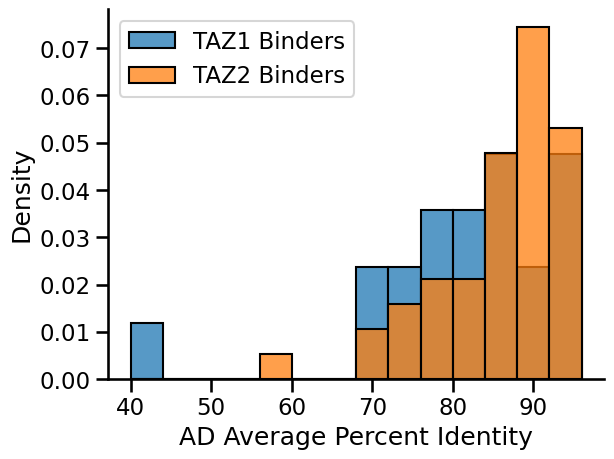

In [465]:
bins = np.arange(40, 100, 4)
plt.figure(dpi = 100)
sns.set_context('talk')
sns.histplot(TAZ1_binders["percent_identity"], bins = bins, stat = 'density', label = "TAZ1 Binders")
sns.histplot(TAZ2_binders["percent_identity"], bins = bins, stat = 'density', label = "TAZ2 Binders")

plt.xlabel("AD Average Percent Identity")
sns.despine()
plt.legend();

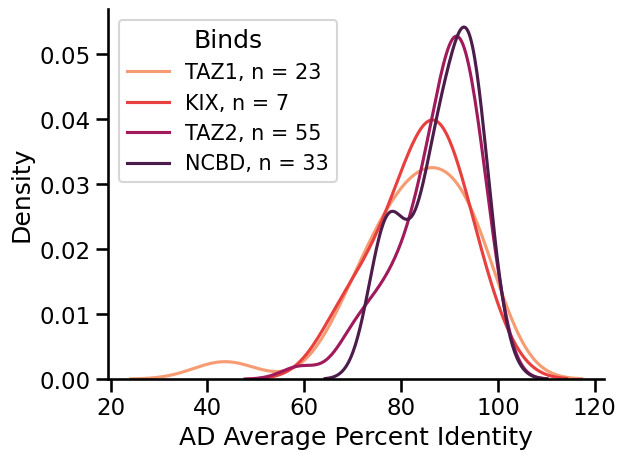

In [488]:
bins = np.arange(40, 100, 4)
plt.figure(dpi = 100)

palette = sns.color_palette('rocket_r', 4)

sns.set_context('talk')
sns.kdeplot(TAZ1_binders["percent_identity"], label = "TAZ1, n = " + str(len(TAZ1_binders)), color = palette[0])

sns.kdeplot(KIX_binders["percent_identity"], label = "KIX, n = " + str(len(KIX_binders)), color = palette[1])
sns.kdeplot(TAZ2_binders["percent_identity"], label = "TAZ2, n = " + str(len(TAZ2_binders)), color = palette[2])
sns.kdeplot(NCBD_binders["percent_identity"], label = "NCBD, n = " + str(len(NCBD_binders)), color = palette[3])

plt.xlabel("AD Average Percent Identity")

sns.despine()
plt.legend(title = "Binds", fontsize = 'small');


In [505]:
# What if I look at average percent identity of the full protein?

In [516]:
gene_cons = TF_interactions_all_pos_cons[["Gene", "P300 KIX binder", "P300 TAZ2 binder", "P300 TAZ1 binder", "P300 NCBD binder", "percent_identity"]].groupby("Gene").mean().reset_index()
gene_cons

,Gene,P300 KIX binder,P300 TAZ2 binder,P300 TAZ1 binder,P300 NCBD binder,percent_identity
0,AKAP8,0.0,1.0,0.0,0.0,81.803850
1,ARGFX,0.0,0.0,0.0,0.0,48.518519
2,ARNTL,0.0,1.0,0.0,1.0,97.264418
3,ARNTL2,0.0,1.0,0.0,0.0,79.454323
4,ATF4,0.0,1.0,1.0,0.0,87.376100
...,...,...,...,...,...,...
105,TRAFD1,0.0,1.0,0.0,0.0,80.169134
106,TRERF1,0.0,1.0,0.0,0.0,87.970669
107,ZNF200,0.0,0.0,0.0,0.0,76.866385
108,ZNF644,0.0,1.0,0.0,0.0,92.354840


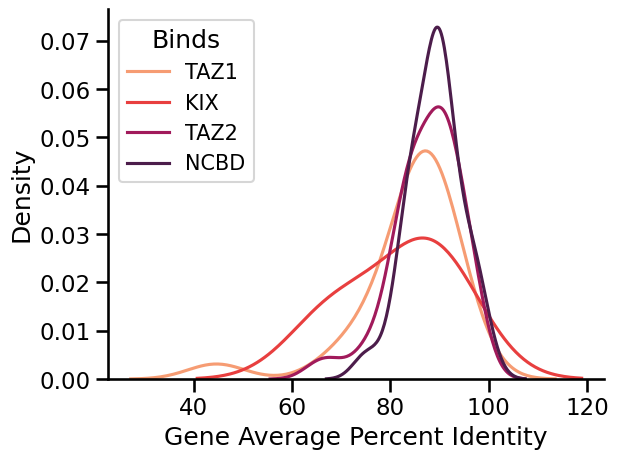

In [521]:
bins = np.arange(40, 100, 4)
plt.figure(dpi = 100)

palette = sns.color_palette('rocket_r', 4)

sns.set_context('talk')
sns.kdeplot(gene_cons[gene_cons["P300 TAZ1 binder"] == 1]["percent_identity"], label = "TAZ1", color = palette[0])
sns.kdeplot(gene_cons[gene_cons["P300 KIX binder"] == 1]["percent_identity"], label = "KIX", color = palette[1])
sns.kdeplot(gene_cons[gene_cons["P300 TAZ2 binder"] == 1]["percent_identity"], label = "TAZ2", color = palette[2])
sns.kdeplot(gene_cons[gene_cons["P300 NCBD binder"] == 1]["percent_identity"], label = "NCBD", color = palette[3])

plt.xlabel("Gene Average Percent Identity")

sns.despine()
plt.legend(title = "Binds", fontsize = 'small');
